# SomaTrack Pain Prediction — 4 Target Analysis

Professional, presentation-ready extension of the SomaTrack workflow with four pain targets.

## Table of Contents
1. Imports & configuration
2. Data loading & dataset overview
3. Missing values, class balance, and correlation analysis
4. Preprocessing & feature engineering
5. Separate models experiment
6. Multi-output experiment
7. 3-target vs 4-target comparison
8. Exported artifacts and conclusion

## Methodology Notes
- Targets: Q22 Back Pain, Q23 Neck Pain, Q24 Headache, Q26 Eye Strain
- The original CSV stores Eye Strain in Q26, while Q25 is Wrist Pain; this notebook follows the dataset schema
- Primary metric: Macro-F1
- Secondary metric: Accuracy
- Leakage control: all pain-related columns removed from the feature matrix

Loaded 270 rows and 34 columns from SomaTrack_—_Study_Habits_&_Physical_Health_Survey_Responses_Form.csv

Head:


,Timestamp,"Q1. On average, how many hours per day do you spend studying while sitting?",Q2. How many days do you study per week?,Q3. What is the longest continuous sitting time without a break ?,Q4. Do you take breaks while studying?,Q5. How long does your break usually last ?,"Q6. During study breaks, do you usually leave your desk?",Q7. How many liters of water do you drink on a typical study day?,Q8. How often do you consume caffeinated or energy drinks during study periods?,Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?,...,Q24. How often have you experienced TENSION HEADACHES linked to study sessions?,Q25. How often have you experienced WRIST PAIN linked to study sessions?,Q26. How often have you experienced EYE STRAIN linked to study sessions?,Q27. How often have you experienced FINGER NUMBNESS linked to study sessions?,"Q28. Overall, what best describes your general physical discomfort level related to studying?",Q29. Age,Q30. Gender,Q31. What type of institution do you attend ?,Q32. What's your main field of study ?,Q33. What is your current year of study?
0,2/27/2026 23:43:22,12.0,7,4.0,Every 1-2 hours,5 - 10 minutes,Sometimes,1-1.5L,+2 drinks per day,4.0,...,1 — Mild / occasional (once or twice),1 — Mild / occasional (once or twice),2 — Moderate / regular (a few times a week),1 — Mild / occasional (once or twice),2 — Frequent discomfort (affects my focus),22.0,Female,Public University,Medical & Health Sciences,4th year
1,2/28/2026 9:54:51,2.0,5,2.0,Every 30-60 minutes,10 - 30 minutes,"Yes, I walk or move around or just lie down on...",1-1.5L,Never,3.0,...,3 — Frequent / chronic (almost daily),2 — Moderate / regular (a few times a week),2 — Moderate / regular (a few times a week),1 — Mild / occasional (once or twice),2 — Frequent discomfort (affects my focus),23.0,Female,Other,Medical & Health Sciences,5th year
2,3/4/2026 19:30:49,2.0,7,2.0,Every 1-2 hours,More than 30 minutes,"Yes, I walk or move around or just lie down on...",More than 2L,1–2 times per week,6.0,...,3 — Frequent / chronic (almost daily),0 — Never,3 — Frequent / chronic (almost daily),3 — Frequent / chronic (almost daily),3 — Chronic pain (affects my daily life),20.0,Female,National Higher School (École Superieure),Computer Science & Artificial Intelligence,3rd year
3,3/4/2026 19:32:54,6.0,6,3.0,Every 1-2 hours,10 - 30 minutes,"Yes, I walk or move around or just lie down on...",1-1.5L,3–5 times per week,6.0,...,1 — Mild / occasional (once or twice),0 — Never,2 — Moderate / regular (a few times a week),0 — Never,1 — Mild / occasional discomfort,20.0,Male,National Higher School (École Superieure),Computer Science & Artificial Intelligence,3rd year
4,3/4/2026 19:35:48,6.0,4,2.0,Every 30-60 minutes,5 - 10 minutes,"Yes, I walk or move around or just lie down on...",1-1.5L,Never,12.0,...,2 — Moderate / regular (a few times a week),0 — Never,0 — Never,0 — Never,1 — Mild / occasional discomfort,21.0,Male,National Higher School (École Superieure),Computer Science & Artificial Intelligence,3rd year


,Metric,Value
0,Rows,270
1,Columns,34
2,Missing columns,7
3,Numeric columns,5
4,Categorical columns,29


,Column,missing_count,missing_pct
0,Q33. What is your current year of study?,10,3.7000
1,Q29. Age,7,2.5900
2,Q32. What's your main field of study ?,7,2.5900
3,Q30. Gender,6,2.2200
4,Q31. What type of institution do you attend ?,5,1.8500
5,Q10. How would you rate your stress level during study periods?,2,0.7400
6,"Q18. On average, how heavy is your backpack on a typical study day?",1,0.3700


,Target,Class,Count,Share %
0,back,0,25,9.2600
1,back,1,87,32.2200
2,back,2,93,34.4400
3,back,3,65,24.0700
4,neck,0,44,16.3000
5,neck,1,109,40.3700
6,neck,2,83,30.7400
7,neck,3,34,12.5900
8,headache,0,44,16.3000
9,headache,1,110,40.7400


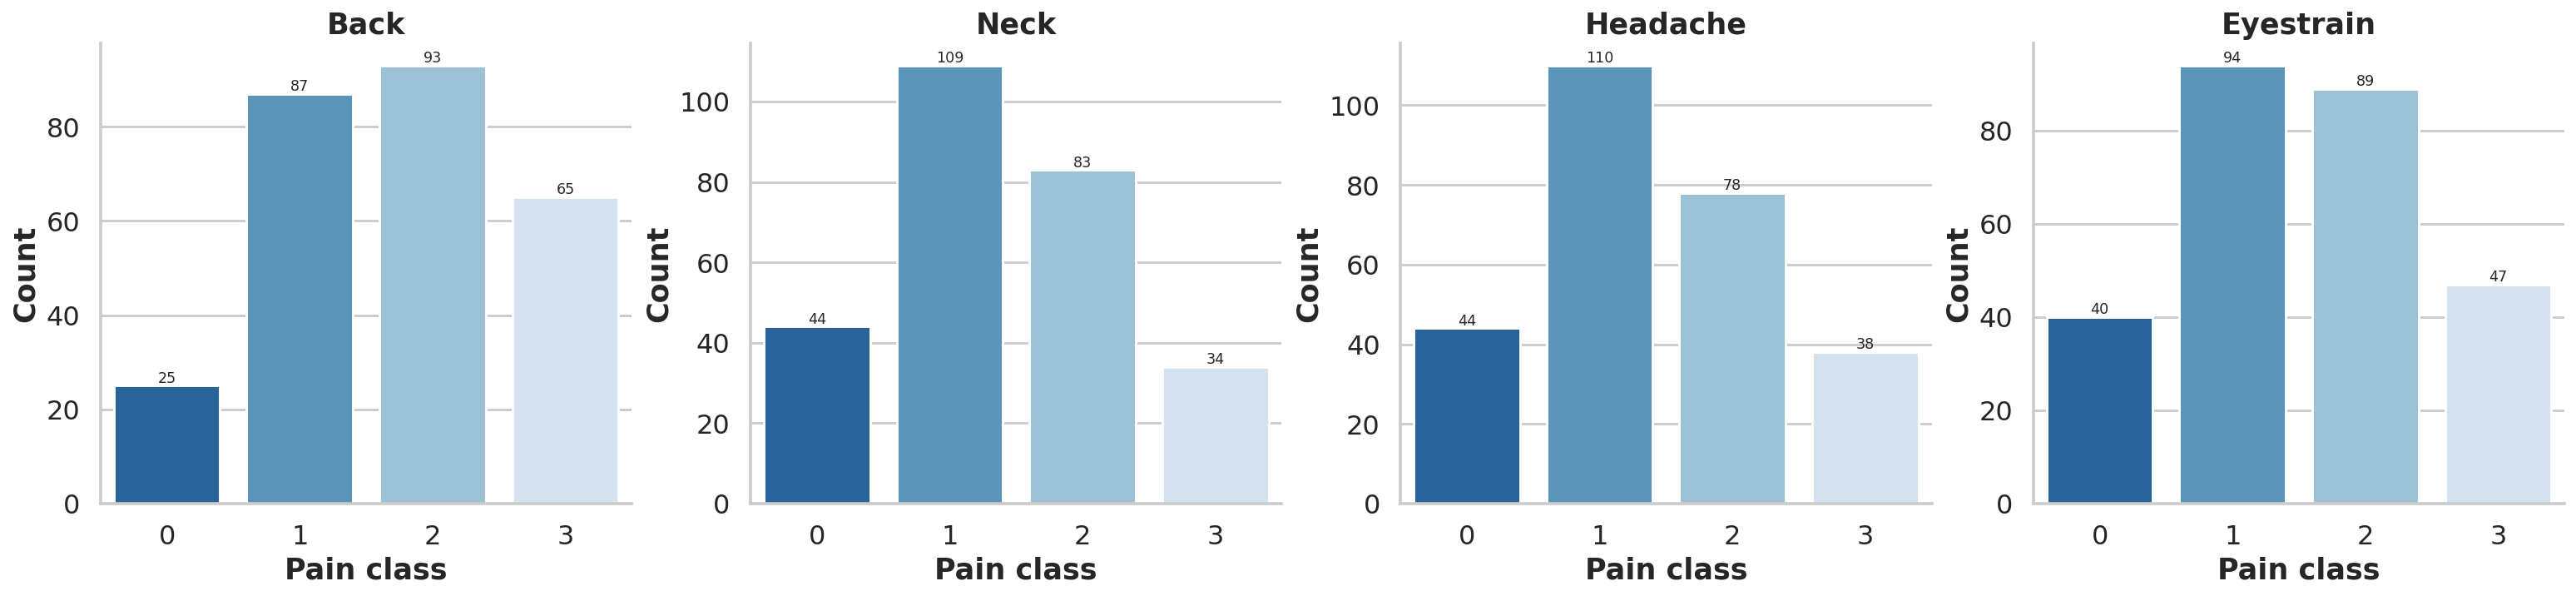

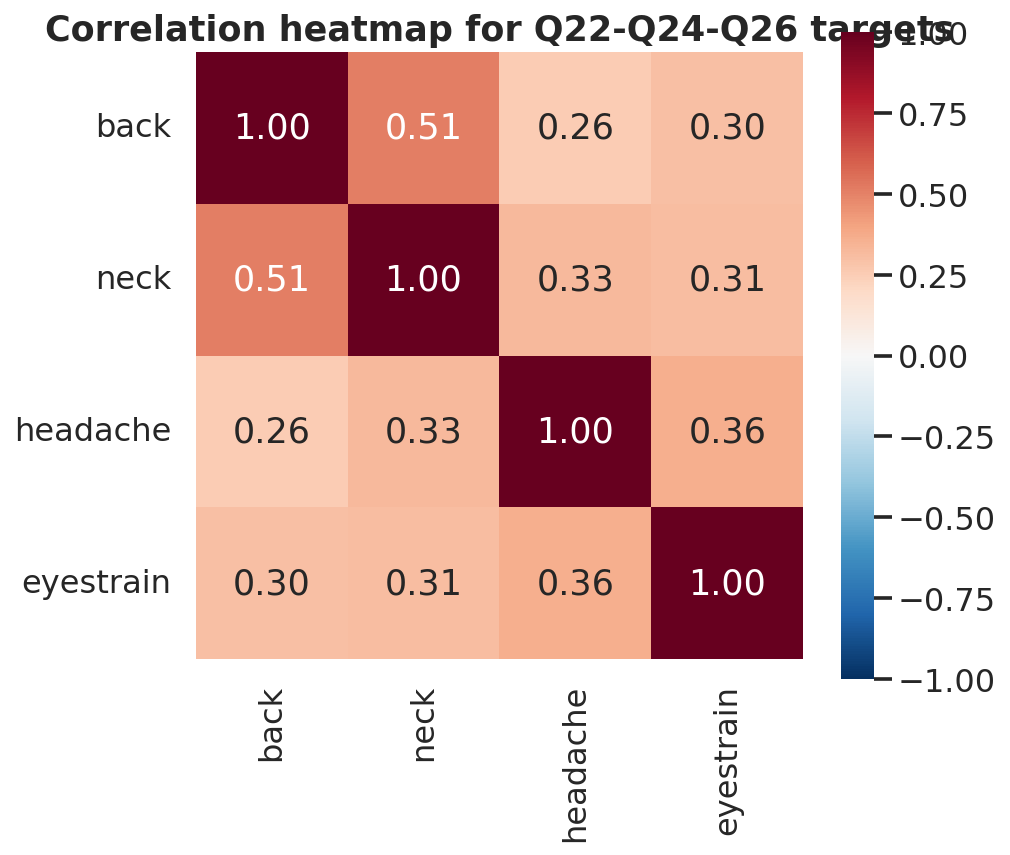

Feature columns after leakage removal: 27
Q25 is excluded from predictors because it is a pain outcome in the raw survey.


Notebook 2 setup complete.


In [7]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 180,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
DATA_CANDIDATES = [
    BASE_DIR / 'data' / 'SomaTrack_—_Study_Habits_&_Physical_Health_Survey_Responses_Form.csv',
    BASE_DIR / 'data' / 'SomaTrack — Study Habits & Physical Health Survey Responses Form.csv',
    BASE_DIR / 'data' / 'SomaTrack — Study Habits & Physical Health Survey.csv',
    BASE_DIR / 'data' / 'SomaTrack_Study_Habits_Physical_Health_Survey_Responses_Form.csv',
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    data_dir = BASE_DIR / 'data'
    raise FileNotFoundError(f"Could not locate the SomaTrack CSV file in {data_dir}.")

REPORT_DIR = BASE_DIR / "models" / "4target_report_assets"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = {
    'back': 'Q22. How often have you experienced BACK PAIN while or after studying?',
    'neck': 'Q23. How often have you experienced NECK STRAIN while or after studying?',
    'headache': 'Q24. How often have you experienced TENSION HEADACHES linked to study sessions?',
    'eyestrain': 'Q26. How often have you experienced EYE STRAIN linked to study sessions?',
}
TARGET_COLUMNS = list(TARGETS.values())
LEAKAGE_PREFIXES = ('Q22.', 'Q23.', 'Q24.', 'Q25.', 'Q26.', 'Q27.')

LABEL_MAP = {0: 'Never', 1: 'Mild', 2: 'Moderate', 3: 'Frequent'}


def fig_save(path: Path, dpi: int = 180):
    plt.savefig(path, dpi=dpi, bbox_inches='tight')


def style_table(frame: pd.DataFrame, caption: str):
    return (
        frame.style
        .set_caption(caption)
        .format(precision=4, na_rep='—')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#111827'), ('color', 'white'), ('font-weight', '700')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '16px'), ('font-weight', '700')]},
            {'selector': 'td', 'props': [('padding', '8px 10px')]},
        ])
    )


def to_label(series):
    return pd.to_numeric(series.astype(str).str.extract(r'(\d+)')[0], errors='coerce')


def load_data(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, encoding='utf-8-sig')
    frame.columns = frame.columns.str.strip()
    return frame


df = load_data(DATA_PATH)
print(f'Loaded {len(df)} rows and {len(df.columns)} columns from {DATA_PATH.name}')
print('\nHead:')
display(df.head())

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

dataset_overview = pd.DataFrame([
    {'Metric': 'Rows', 'Value': df.shape[0]},
    {'Metric': 'Columns', 'Value': df.shape[1]},
    {'Metric': 'Missing columns', 'Value': int((df.isna().sum() > 0).sum())},
    {'Metric': 'Numeric columns', 'Value': int(df.select_dtypes(include=[np.number]).shape[1])},
    {'Metric': 'Categorical columns', 'Value': int(df.select_dtypes(include=['object']).shape[1])},
])
display(style_table(dataset_overview, 'Dataset overview'))
if not missing_df.empty:
    display(style_table(missing_df.head(15).reset_index().rename(columns={'index': 'Column'}), 'Top missing-value columns'))

# Targets and leakage-safe feature matrix
y_df = pd.DataFrame({name: to_label(df[col]) for name, col in TARGETS.items()})
valid_mask = y_df.notna().all(axis=1)
df = df.loc[valid_mask].reset_index(drop=True)
y_df = y_df.loc[valid_mask].reset_index(drop=True)
X = df.drop(columns=[col for col in df.columns if col.startswith(LEAKAGE_PREFIXES)], errors='ignore').drop(columns=['Timestamp'], errors='ignore')

class_rows = []
for target_name in y_df.columns:
    counts = y_df[target_name].value_counts().sort_index()
    for cls, cnt in counts.items():
        class_rows.append({'Target': target_name, 'Class': int(cls), 'Count': int(cnt), 'Share %': round(100 * cnt / len(y_df), 2)})
class_df = pd.DataFrame(class_rows)
display(style_table(class_df, 'Target class distributions'))

fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
for ax, (key, col) in zip(axes, TARGETS.items()):
    counts = y_df[key].value_counts().sort_index()
    plot_df = counts.rename_axis('Class').reset_index(name='Count')
    sns.barplot(data=plot_df, x='Class', y='Count', ax=ax, palette='Blues_r')
    ax.set_title(key.title())
    ax.set_xlabel('Pain class')
    ax.set_ylabel('Count')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9)
fig_save(REPORT_DIR / 'target_distributions.png')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(y_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation heatmap for Q22-Q24-Q26 targets')
fig_save(REPORT_DIR / 'target_correlation_heatmap.png')
plt.show()

print(f'Feature columns after leakage removal: {X.shape[1]}')
print(f'Q25 is excluded from predictors because it is a pain outcome in the raw survey.')

missing_df.to_csv(REPORT_DIR / 'missing_values.csv')
class_df.to_csv(REPORT_DIR / 'target_distribution.csv', index=False)
dataset_overview.to_csv(REPORT_DIR / 'dataset_overview.csv', index=False)

TOC = [
    ('Imports & configuration', '#imports--configuration'),
    ('Data loading & EDA', '#data-loading--eda'),
    ('Modeling', '#modeling'),
    ('3-target vs 4-target comparison', '#3-target-vs-4-target-comparison'),
    ('Export & conclusion', '#exported-artifacts-and-conclusion'),
]

def show_toc(items=TOC):
    html = '<div style="padding:12px;border:1px solid #e5e7eb;border-radius:12px;background:#fafafa"><h3 style="margin-top:0">Table of Contents</h3><ul>'
    for title, anchor in items:
        html += f'<li><a href="{anchor}">{title}</a></li>'
    html += '</ul></div>'
    display(HTML(html))

show_toc()
print('Notebook 2 setup complete.')

## Modeling

This section follows the same experimental structure as the original notebook, but extends the target set to include Q26 Eye Strain.

,Metric,Value
0,Separate avg Macro-F1,0.3472
1,Separate avg Accuracy,0.3688
2,Best multi-output avg Macro-F1,0.3216
3,Best multi-output exact-match,0.0111


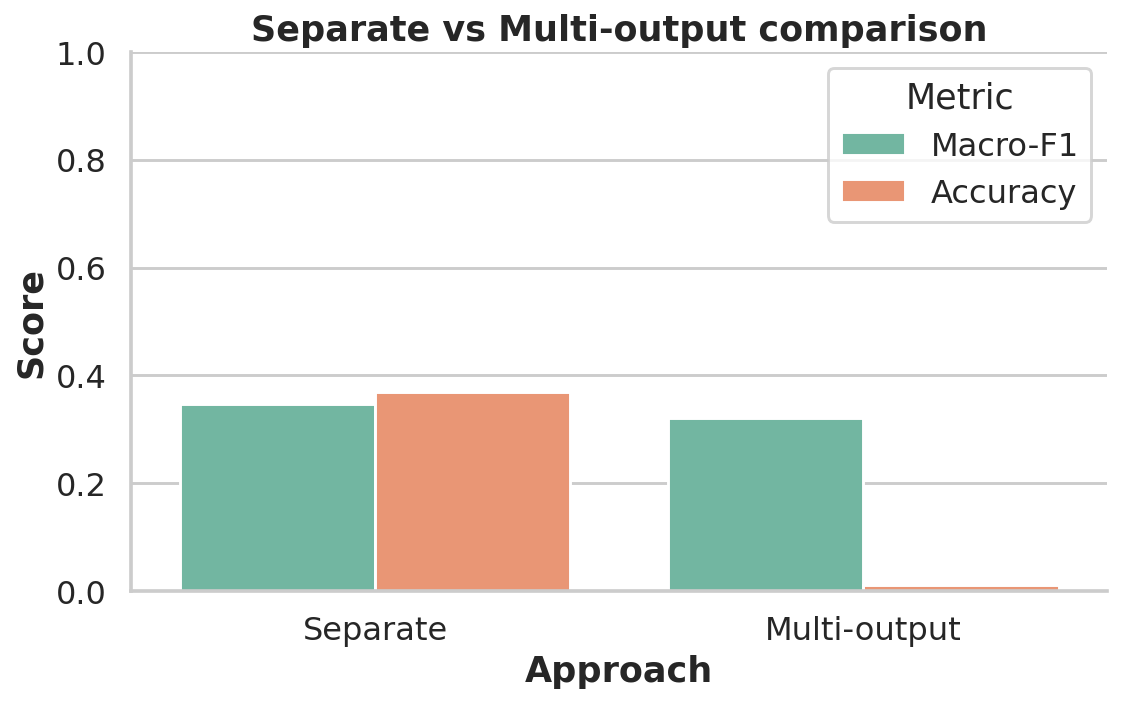

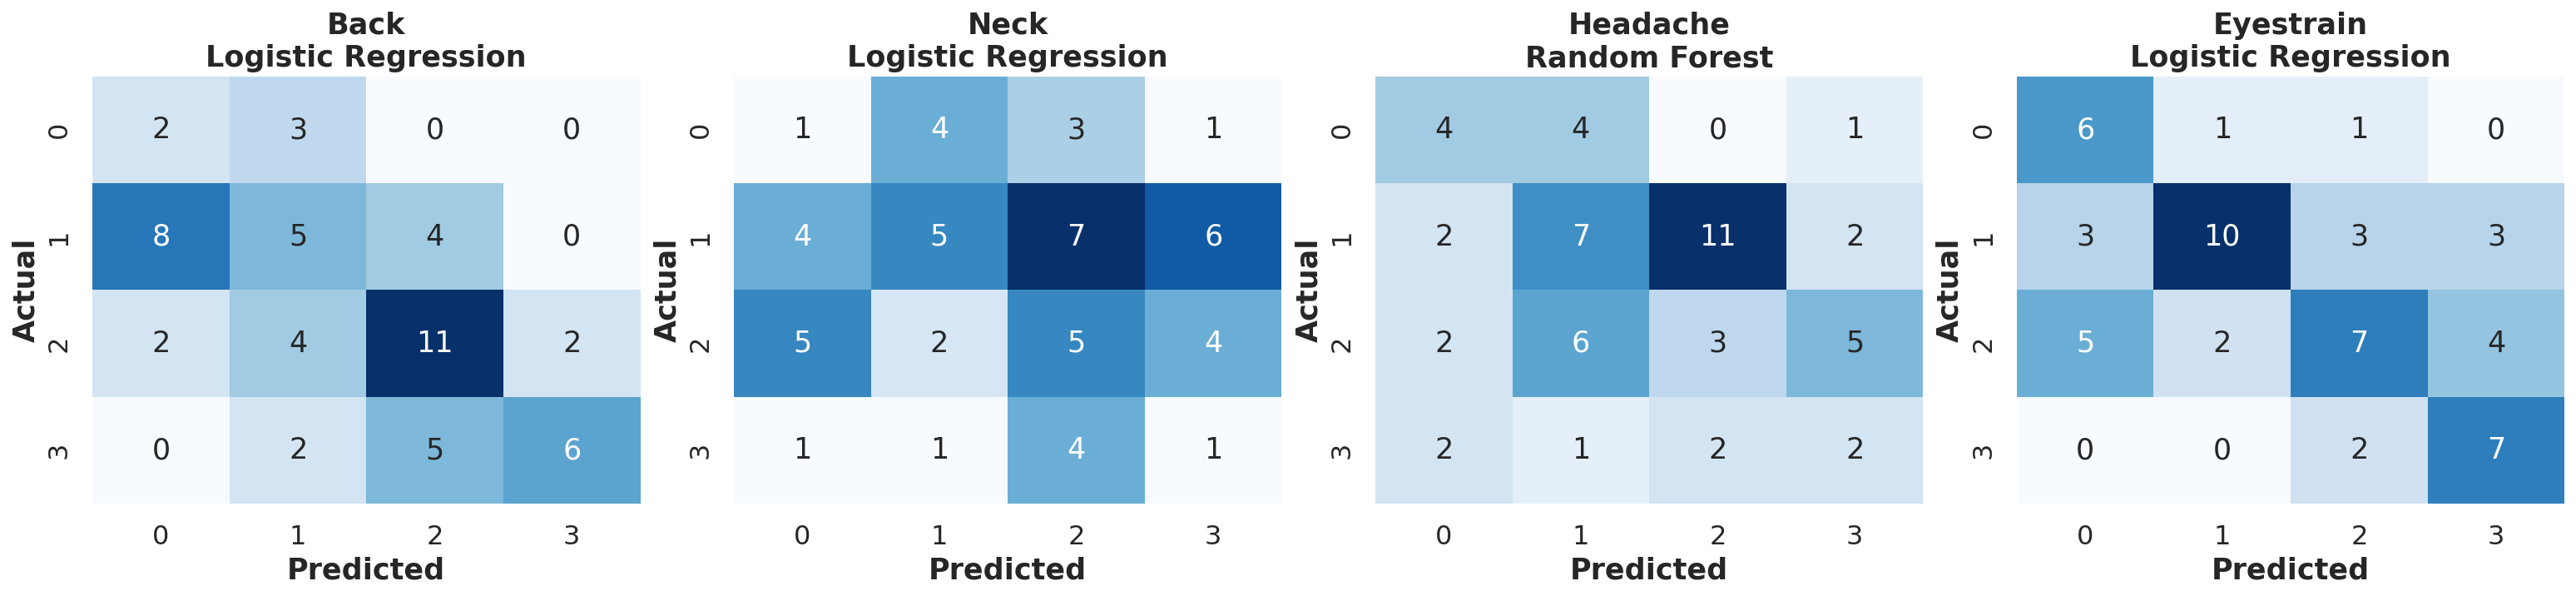

,target,feature,importance
0,back,backpack_load_risk,0.0333
1,back,Q33. What is your current year of study?,0.0279
2,back,Q30. Gender,0.0278
3,back,"Q28. Overall, what best describes your general physical discomfort level related to studying?",0.0258
4,back,screen_exposure_load,0.0242
5,back,"Q17. Do you have any pre-existing medical condition or past injury affecting your back, neck, shoulders, or wrists?",0.0159
6,back,Q21. What's your average sleep duration per night ?,0.0155
7,back,Q19. How would you describe your usual study lighting conditions?,0.0148
24,eyestrain,Q19. How would you describe your usual study lighting conditions?,0.0717
25,eyestrain,"Q18. On average, how heavy is your backpack on a typical study day?",0.0640


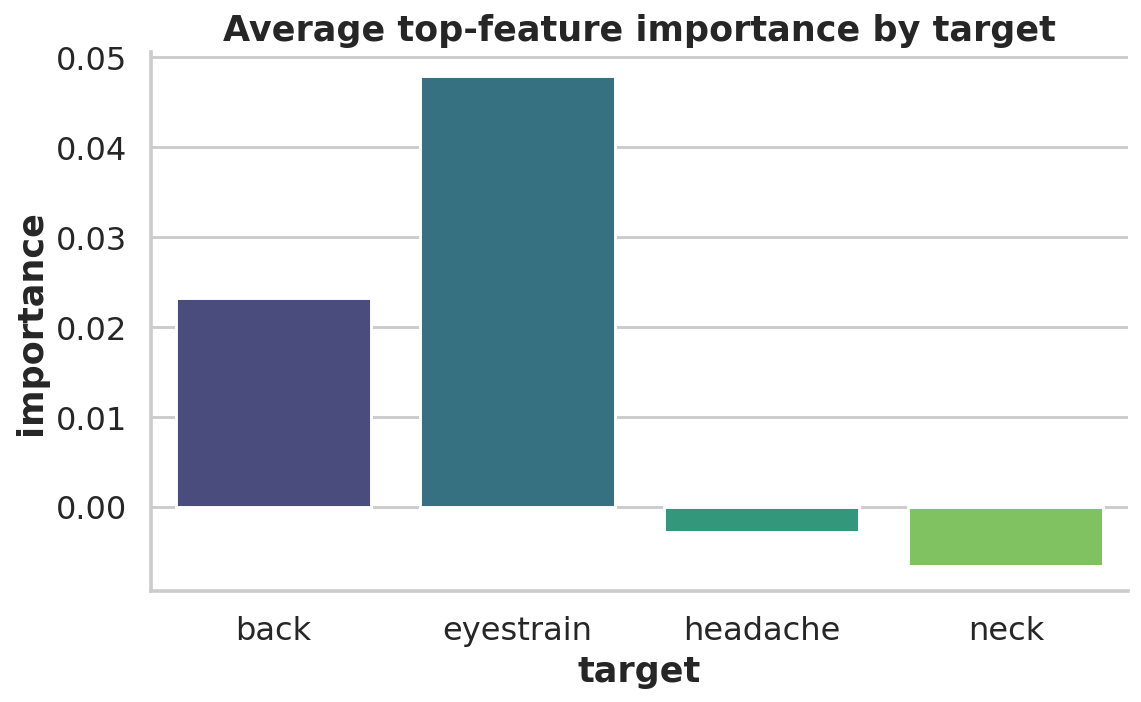

4-target modeling complete.


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

NUMERIC_SOURCE_COLUMNS = [
    'Q1. On average, how many hours per day do you spend studying while sitting?',
    'Q2. How many days do you study per week?',
    'Q3. What is the longest continuous sitting time without a break ?',
    'Q9. What is your average daily screen time (phone + laptop/tablet combined) in hours ?',
    'Q29. Age',
]
ORDINAL_MAP = {
    'Q4. Do you take breaks while studying?': ['Never', 'Rarely', 'Every 1-2 hours', 'Every 30-60 minutes'],
    'Q5. How long does your break usually last ?': ["I don't take breaks", 'Less than 5 minutes', '5 - 10 minutes', '10 - 30 minutes', 'More than 30 minutes'],
    'Q7. How many liters of water do you drink on a typical study day?': ['Less than 1L', '1-1.5L', '1.5-2L', 'More than 2L'],
    'Q8. How often do you consume caffeinated or energy drinks during study periods?': ['Never', '1 drink per day', '1–2 times per week', '3–5 times per week', '+2 drinks per day'],
    'Q10. How would you rate your stress level during study periods?': ['Low', 'Moderate', 'High'],
    'Q14. How would you describe your posture during most study sessions?': ['Lying down', 'Heavily slouched / hunched', 'Slightly slouched', 'Upright / straight back'],
    'Q15. Do you usually lean on your back while studying?': ['No', 'Sometimes', 'Yes'],
    'Q16. Is your screen at eye level when you study?': ['No, I look down at it most of the time', 'Sometimes', 'Yes, always'],
    'Q18. On average, how heavy is your backpack on a typical study day?': ['Less than 3 kg', '3–5 kg', '5–8 kg', 'More than 8 kg'],
    'Q20. Do you practice physical exercise weekly?': ['No', '1 – 2 times', '3 – 4 times', '+5 times'],
    "Q21. What's your average sleep duration per night ?": ['Less than 5h', '5 – 6h', '6 – 7h', '7 – 8h', 'More than 8h'],
}
CATEGORICAL_COLUMNS = [
    'Q6. During study breaks, do you usually leave your desk?',
    'Q11. Where do you primarily study?',
    'Q12. What type of seat do you most often use while studying?',
    'Q13. When working on a laptop, what input method do you primarily use?',
    'Q17. Do you have any pre-existing medical condition or past injury affecting your back, neck, shoulders, or wrists?',
    'Q19. How would you describe your usual study lighting conditions?',
    'Q30. Gender ',
    'Q31. What type of institution do you attend ?',
    "Q32. What's your main field of study ?",
    'Q33. What is your current year of study?',
]

feature_df = X.copy()
for col in NUMERIC_SOURCE_COLUMNS:
    feature_df[col] = pd.to_numeric(feature_df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

q1 = feature_df[NUMERIC_SOURCE_COLUMNS[0]]
q2 = feature_df[NUMERIC_SOURCE_COLUMNS[1]]
q3 = feature_df[NUMERIC_SOURCE_COLUMNS[2]]
q9 = feature_df[NUMERIC_SOURCE_COLUMNS[3]]
q29 = feature_df[NUMERIC_SOURCE_COLUMNS[4]]

break_freq = feature_df['Q4. Do you take breaks while studying?'].astype(str).str.strip().map({'Never': 0, 'Rarely': 1, 'Every 1-2 hours': 2, 'Every 30-60 minutes': 3}).fillna(0)
sleep = feature_df["Q21. What's your average sleep duration per night ?"].astype(str).str.strip().map({'Less than 5h': 0, '5 – 6h': 1, '6 – 7h': 2, '7 – 8h': 3, 'More than 8h': 4}).fillna(0)
stress = feature_df['Q10. How would you rate your stress level during study periods?'].astype(str).str.strip().map({'Low': 0, 'Moderate': 1, 'High': 2}).fillna(0)
posture = feature_df['Q14. How would you describe your posture during most study sessions?'].astype(str).str.strip().map({'Lying down': 0, 'Heavily slouched / hunched': 1, 'Slightly slouched': 2, 'Upright / straight back': 3}).fillna(0)
eye_level = feature_df['Q16. Is your screen at eye level when you study?'].astype(str).str.strip().map({'No, I look down at it most of the time': 0, 'Sometimes': 1, 'Yes, always': 2}).fillna(0)
exercise = feature_df['Q20. Do you practice physical exercise weekly?'].astype(str).str.strip().map({'No': 0, '1 – 2 times': 1, '3 – 4 times': 2, '+5 times': 3}).fillna(0)
water = feature_df['Q7. How many liters of water do you drink on a typical study day?'].astype(str).str.strip().map({'Less than 1L': 0, '1-1.5L': 1, '1.5-2L': 2, 'More than 2L': 3}).fillna(0)
seat_bad = feature_df['Q12. What type of seat do you most often use while studying?'].astype(str).str.contains('Bed / floor|Stool|Wooden chair|Plastic chair|Sofa', case=False, na=False).astype(int)
study_bed = feature_df['Q11. Where do you primarily study?'].astype(str).str.contains('Bed|Desk (at home/dorm)', case=False, na=False, regex=True).astype(int)

feature_df['study_intensity'] = q1 * q2
feature_df['continuous_sitting_burden'] = q1 * q3
feature_df['screen_exposure_load'] = q1 * q9
feature_df['sedentary_risk'] = q3.fillna(q3.median()) + (3 - break_freq) + (3 - exercise)
feature_df['ergonomic_risk'] = (3 - posture) + (2 - eye_level) + seat_bad
feature_df['recovery_score'] = break_freq + sleep + exercise
feature_df['lifestyle_burden'] = stress + (4 - sleep) + (3 - exercise)
feature_df['hydration_caffeine_risk'] = (3 - water) + feature_df['Q8. How often do you consume caffeinated or energy drinks during study periods?'].astype(str).str.strip().map({'Never': 0, '1 drink per day': 1, '1–2 times per week': 2, '3–5 times per week': 3, '+2 drinks per day': 4}).fillna(0)
feature_df['posture_ergonomics_mismatch'] = (3 - posture) + (2 - eye_level)
feature_df['backpack_load_risk'] = feature_df['Q18. On average, how heavy is your backpack on a typical study day?'].astype(str).str.strip().map({'Less than 3 kg': 0, '3–5 kg': 1, '5–8 kg': 2, 'I rarely carry a backpack': 0, 'More than 8 kg': 3}).fillna(0)
feature_df['environment_support_score'] = feature_df['Q19. How would you describe your usual study lighting conditions?'].astype(str).str.strip().map({'Natural daylight': 2, 'Bright artificial lighting': 2, 'Mixed (natural + artificial)': 1, 'Dim lighting': 0}).fillna(0) + study_bed
feature_df['overall_risk_score'] = (
    0.20 * feature_df['sedentary_risk'] + 0.20 * feature_df['ergonomic_risk'] + 0.15 * feature_df['lifestyle_burden'] +
    0.10 * feature_df['hydration_caffeine_risk'] + 0.10 * feature_df['posture_ergonomics_mismatch'] +
    0.10 * feature_df['backpack_load_risk'] + 0.10 * (3 - feature_df['environment_support_score']) +
    0.05 * q1.fillna(q1.median()) + 0.05 * q9.fillna(q9.median())
)

score_cols = [c for c in feature_df.columns if c.endswith('_risk') or c.endswith('_score') or c in ['study_intensity', 'continuous_sitting_burden', 'screen_exposure_load']]
for col in score_cols:
    s = feature_df[col].astype(float)
    feature_df[col] = (s - s.min()) / (s.max() - s.min() + 1e-9)

X_model = feature_df.drop(columns=TARGET_COLUMNS, errors='ignore').drop(columns=['Timestamp'], errors='ignore')
X_model = X_model[[c for c in X_model.columns if not c.startswith(LEAKAGE_PREFIXES)]]
Y = y_df.copy()

numeric_features = X_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_model.select_dtypes(include=['object']).columns.tolist()
ordinal_features = [c for c in ORDINAL_MAP if c in X_model.columns]
ordinal_categories = [ORDINAL_MAP[c] for c in ordinal_features]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('enc', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))]), ordinal_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), [c for c in categorical_features if c not in ordinal_features]),
], remainder='drop', verbose_feature_names_out=False)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=3, class_weight='balanced_subsample', random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
}
sep_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
separate_results = {}
trained_separate_models = {}

for target_name in TARGETS:
    y_target = Y[target_name]
    rows = []
    for model_name, model in base_models.items():
        pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
        scores = cross_validate(pipe, X_model, y_target, cv=sep_cv, scoring={'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro', 'f1_macro': 'f1_macro'}, n_jobs=-1)
        pipe.fit(X_model, y_target)
        trained_separate_models[f'{target_name}_{model_name}'] = pipe
        rows.append({
            'approach': 'separate', 'target': target_name, 'model': model_name,
            'cv_accuracy_mean': scores['test_accuracy'].mean(), 'cv_accuracy_std': scores['test_accuracy'].std(),
            'cv_precision_macro_mean': scores['test_precision_macro'].mean(), 'cv_recall_macro_mean': scores['test_recall_macro'].mean(),
            'cv_f1_macro_mean': scores['test_f1_macro'].mean(), 'cv_f1_macro_std': scores['test_f1_macro'].std(),
        })
    separate_results[target_name] = pd.DataFrame(rows)

multi_models = base_models
multi_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
multi_output_rows = []
trained_multi_models = {}

for model_name, model in multi_models.items():
    fold_f1 = []
    fold_exact = []
    fold_f1_by_target = {t: [] for t in Y.columns}
    for train_idx, test_idx in multi_cv.split(X_model):
        X_tr, X_te = X_model.iloc[train_idx], X_model.iloc[test_idx]
        Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]
        pipe = Pipeline([('preprocess', preprocessor), ('model', MultiOutputClassifier(model))])
        pipe.fit(X_tr, Y_tr)
        preds = pipe.predict(X_te)
        per_target_f1 = []
        for idx, t in enumerate(Y.columns):
            score = f1_score(Y_te.iloc[:, idx], preds[:, idx], average='macro', zero_division=0)
            fold_f1_by_target[t].append(score)
            per_target_f1.append(score)
        fold_f1.append(float(np.mean(per_target_f1)))
        fold_exact.append(float((Y_te.to_numpy() == preds).all(axis=1).mean()))
    final_pipe = Pipeline([('preprocess', preprocessor), ('model', MultiOutputClassifier(model))])
    final_pipe.fit(X_model, Y)
    trained_multi_models[model_name] = final_pipe
    multi_output_rows.append({
        'approach': 'multi_output', 'target': 'all', 'model': model_name,
        'cv_avg_f1_macro_mean': float(np.mean(fold_f1)), 'cv_avg_f1_macro_std': float(np.std(fold_f1)),
        'cv_exact_match_mean': float(np.mean(fold_exact)), 'cv_exact_match_std': float(np.std(fold_exact)),
        'target_f1_breakdown': {k: float(np.mean(v)) for k, v in fold_f1_by_target.items()},
    })

separate_all = pd.concat(separate_results.values(), ignore_index=True)
best_sep = separate_all.sort_values('cv_f1_macro_mean', ascending=False)
best_per_target = best_sep.groupby('target', as_index=False).first()
separate_avg_f1 = float(best_per_target['cv_f1_macro_mean'].mean())
separate_avg_acc = float(best_per_target['cv_accuracy_mean'].mean())
best_multi = pd.DataFrame(multi_output_rows).sort_values('cv_avg_f1_macro_mean', ascending=False).iloc[0]
multi_avg_f1 = float(best_multi['cv_avg_f1_macro_mean'])
multi_exact = float(best_multi['cv_exact_match_mean'])

summary_table = pd.DataFrame([
    {'Metric': 'Separate avg Macro-F1', 'Value': separate_avg_f1},
    {'Metric': 'Separate avg Accuracy', 'Value': separate_avg_acc},
    {'Metric': 'Best multi-output avg Macro-F1', 'Value': multi_avg_f1},
    {'Metric': 'Best multi-output exact-match', 'Value': multi_exact},
])
display(style_table(summary_table, 'Original 4-target summary metrics'))

fig, ax = plt.subplots(figsize=(9, 5))
bar_df = pd.DataFrame({'Approach': ['Separate', 'Multi-output'], 'Macro-F1': [separate_avg_f1, multi_avg_f1], 'Accuracy': [separate_avg_acc, multi_exact]})
sns.barplot(data=bar_df.melt(id_vars='Approach', var_name='Metric', value_name='Score'), x='Approach', y='Score', hue='Metric', ax=ax, palette='Set2')
ax.set_title('Separate vs Multi-output comparison')
ax.set_ylim(0, 1)
fig_save(REPORT_DIR / 'separate_vs_multi_comparison.png')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
importance_frames = []
for axis, target_name in zip(axes, TARGETS.keys()):
    best_row = best_per_target[best_per_target['target'] == target_name].iloc[0]
    x_tr, x_te, y_tr, y_te = train_test_split(X_model, Y[target_name], test_size=0.2, random_state=RANDOM_STATE, stratify=Y[target_name])
    model = trained_separate_models[f'{target_name}_{best_row["model"]}']
    preds = model.predict(x_te)
    cm = confusion_matrix(y_te, preds, labels=sorted(Y[target_name].dropna().unique()))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(f'{target_name.title()}\n{best_row["model"]}')
    axis.set_xlabel('Predicted')
    axis.set_ylabel('Actual')
    perm = permutation_importance(model, x_te, y_te, n_repeats=10, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1)
    feature_names = np.array(x_te.columns)
    top_idx = np.argsort(perm.importances_mean)[::-1][:8]
    importance_frames.append(pd.DataFrame({'target': target_name, 'feature': feature_names[top_idx], 'importance': perm.importances_mean[top_idx]}))
fig_save(REPORT_DIR / 'confusion_matrices.png')
plt.show()

importance_df = pd.concat(importance_frames, ignore_index=True)
display(style_table(importance_df.sort_values(['target', 'importance'], ascending=[True, False]), 'Permutation importance (top features)'))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance_df.groupby('target', as_index=False)['importance'].mean(), x='target', y='importance', ax=ax, palette='viridis')
ax.set_title('Average top-feature importance by target')
fig_save(REPORT_DIR / 'feature_importance_summary.png')
plt.show()

# 3-target comparison hook
comparison = {
    'three_target_summary_path': str(BASE_DIR / 'models' / '3target_report_assets' / 'decision_summary.json'),
    'four_target_summary_path': str(REPORT_DIR / 'decision_summary.json'),
}
print('4-target modeling complete.')

## 3-target vs 4-target comparison

This section reads the exported 3-target summary when available and contrasts the original three-target workflow with the four-target extension.

,Analysis,Targets,Separate Macro-F1,Multi-output Macro-F1,Exact Match
0,3-target original,3,—,—,—
1,4-target extended,4,0.3472,0.3216,0.0111


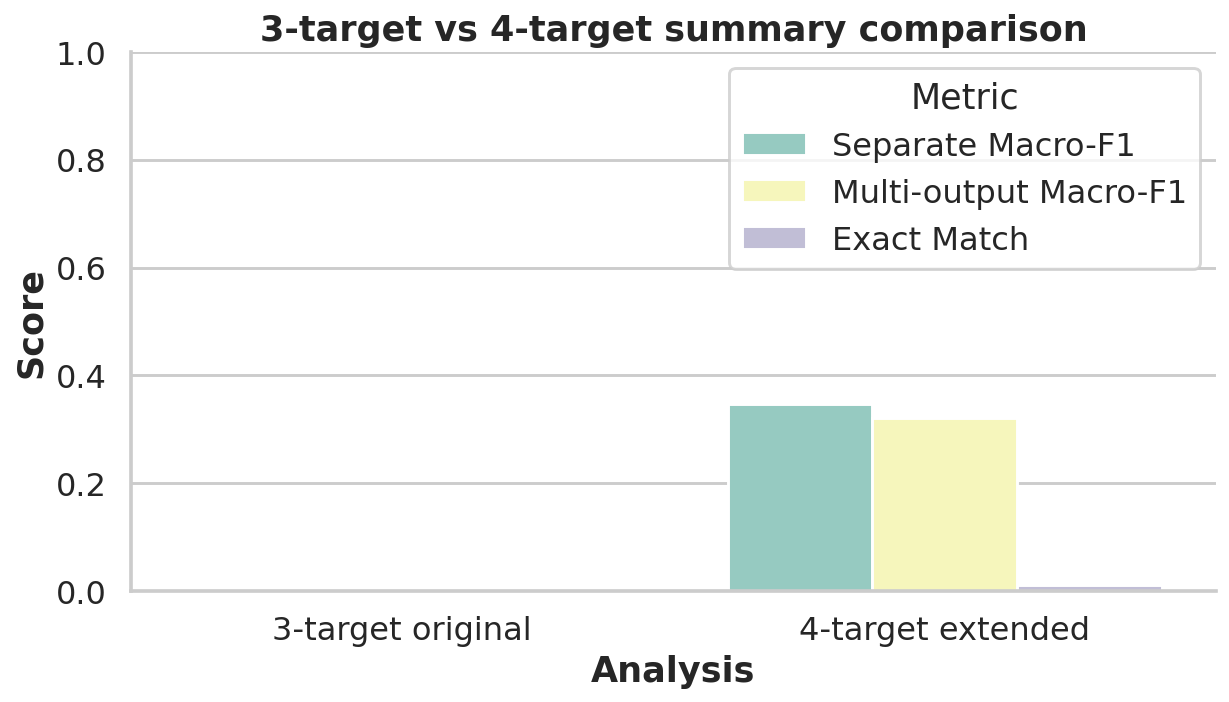

Comparison saved to: /home/asmaa/Documents/3rd year/2nd semester/ML/project/SomaTrack---Predicting-Study-Related-Physical-Ailments-ML-based-System/models/4target_report_assets/three_vs_four_comparison.csv
4-target notebook exports complete.


In [9]:
three_summary_path = BASE_DIR / 'models' / '3target_report_assets' / 'decision_summary.json'
three_results_path = BASE_DIR / 'models' / '3target_report_assets' / 'detailed_results.csv'

three_summary = {}
if three_summary_path.exists():
    with open(three_summary_path, 'r', encoding='utf-8') as f:
        three_summary = json.load(f)

comparison_rows = [
    {
        'Analysis': '3-target original',
        'Targets': 3,
        'Separate Macro-F1': float(three_summary.get('best_separate_avg_f1', np.nan)),
        'Multi-output Macro-F1': float(three_summary.get('best_multi_avg_f1', np.nan)),
        'Exact Match': float(three_summary.get('best_multi_exact_match', np.nan)),
    },
    {
        'Analysis': '4-target extended',
        'Targets': 4,
        'Separate Macro-F1': separate_avg_f1,
        'Multi-output Macro-F1': multi_avg_f1,
        'Exact Match': multi_exact,
    },
]
comparison_df = pd.DataFrame(comparison_rows)
display(style_table(comparison_df, '3-target vs 4-target comparison'))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=comparison_df.melt(id_vars=['Analysis', 'Targets'], var_name='Metric', value_name='Score'), x='Analysis', y='Score', hue='Metric', ax=ax, palette='Set3')
ax.set_title('3-target vs 4-target summary comparison')
ax.set_ylim(0, 1)
fig_save(REPORT_DIR / 'three_vs_four_comparison.png')
plt.show()

comparison_df.to_csv(REPORT_DIR / 'three_vs_four_comparison.csv', index=False)
final_summary = {
    'three_target_summary': three_summary,
    'four_target_summary': {
        'best_separate_avg_f1': separate_avg_f1,
        'best_separate_avg_acc': separate_avg_acc,
        'best_multi_avg_f1': multi_avg_f1,
        'best_multi_exact_match': multi_exact,
        'per_target_best_separate': {
            row['target']: {'model': row['model'], 'f1': float(row['cv_f1_macro_mean']), 'accuracy': float(row['cv_accuracy_mean'])}
            for _, row in best_per_target.iterrows()
        },
    },
    'decision': 'separate' if separate_avg_f1 >= multi_avg_f1 - 0.02 else 'multi',
}
with open(REPORT_DIR / 'decision_summary.json', 'w', encoding='utf-8') as f:
    json.dump(final_summary, f, indent=2)

results_export_df = pd.concat([
    separate_all.assign(analysis='separate', analysis_version='4-target extended'),
    pd.DataFrame(multi_output_rows).assign(analysis='multi_output', analysis_version='4-target extended'),
], ignore_index=True)
results_export_df.to_csv(REPORT_DIR / 'detailed_results.csv', index=False)

for target_name in TARGETS.keys():
    best_row = best_per_target[best_per_target['target'] == target_name].iloc[0]
    joblib.dump(trained_separate_models[f'{target_name}_{best_row["model"]}'], MODELS_DIR / f'4target_{target_name}_{best_row["model"].replace(" ", "_").lower()}.joblib')

joblib.dump(trained_multi_models[best_multi['model']], MODELS_DIR / f'4target_multi_output_{best_multi["model"].replace(" ", "_").lower()}.joblib')

print(f'Comparison saved to: {REPORT_DIR / "three_vs_four_comparison.csv"}')
print('4-target notebook exports complete.')

## Accuracy Summary

This section lists the full accuracy breakdown for each target and model, along with target-level and model-level averages.

In [10]:
accuracy_details = separate_all[['target', 'model', 'cv_accuracy_mean', 'cv_accuracy_std', 'cv_f1_macro_mean']].sort_values(['target', 'cv_accuracy_mean'], ascending=[True, False])
display(style_table(accuracy_details, 'Separate-model accuracy by target and model'))

target_accuracy_summary = separate_all.groupby('target', as_index=False).agg(
    best_accuracy=('cv_accuracy_mean', 'max'),
    mean_accuracy=('cv_accuracy_mean', 'mean'),
    best_f1=('cv_f1_macro_mean', 'max'),
    mean_f1=('cv_f1_macro_mean', 'mean'),
)
display(style_table(target_accuracy_summary, 'Target-level accuracy and F1 averages'))

model_accuracy_summary = separate_all.groupby('model', as_index=False).agg(
    mean_accuracy=('cv_accuracy_mean', 'mean'),
    std_accuracy=('cv_accuracy_mean', 'std'),
    mean_f1=('cv_f1_macro_mean', 'mean'),
    std_f1=('cv_f1_macro_mean', 'std'),
).sort_values('mean_accuracy', ascending=False)
display(style_table(model_accuracy_summary, 'Model-level average accuracy and F1 across targets'))

multi_output_accuracy_summary = pd.DataFrame(multi_output_rows)[['model', 'cv_avg_f1_macro_mean', 'cv_exact_match_mean']].sort_values('cv_avg_f1_macro_mean', ascending=False)
display(style_table(multi_output_accuracy_summary, 'Multi-output average metrics'))

,target,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean
0,back,Logistic Regression,0.4111,0.0628,0.3904
1,back,Random Forest,0.4086,0.0547,0.3568
3,back,Gradient Boosting,0.3975,0.0422,0.3422
2,back,SVM,0.3889,0.0406,0.3610
15,eyestrain,Gradient Boosting,0.3469,0.0551,0.3057
13,eyestrain,Random Forest,0.3444,0.0523,0.2863
12,eyestrain,Logistic Regression,0.3383,0.0560,0.3234
14,eyestrain,SVM,0.3049,0.0501,0.3007
9,headache,Random Forest,0.3815,0.0630,0.3428
11,headache,Gradient Boosting,0.3642,0.0457,0.2977


,target,best_accuracy,mean_accuracy,best_f1,mean_f1
0,back,0.4111,0.4015,0.3904,0.3626
1,eyestrain,0.3469,0.3336,0.3234,0.3040
2,headache,0.3815,0.3426,0.3428,0.3131
3,neck,0.3667,0.3386,0.3323,0.2983


,model,mean_accuracy,std_accuracy,mean_f1,std_f1
0,Gradient Boosting,0.3688,0.0211,0.3125,0.0201
2,Random Forest,0.3645,0.0380,0.3104,0.0476
1,Logistic Regression,0.3466,0.0488,0.3320,0.0446
3,SVM,0.3364,0.0367,0.3231,0.0287


,model,cv_avg_f1_macro_mean,cv_exact_match_mean
0,Logistic Regression,0.3216,0.0111
2,SVM,0.3159,0.0148
3,Gradient Boosting,0.2868,0.0185
1,Random Forest,0.2851,0.0222
